# Notebook 06 — Temporal Smoothing on Video Clips

This is the proposed novel contribution of the project. We process consecutive
frames from a single TuSimple clip with two pipelines:

1. **Raw**: each frame independently (the standard classical CV approach).
2. **Smoothed**: same frames, but polynomial coefficients are EMA-blended
   across frames using `EMASmoother`, with fallback to the previous estimate
   when single-frame detection fails.

We measure two things:
- **Visual stability** by rendering side-by-side videos.
- **Coefficient stability** by plotting how each coefficient evolves frame-to-frame.

The key claim of this section: temporal smoothing reduces frame-to-frame jitter
and recovers lanes that the single-frame pipeline misses, without significant
extra computational cost.

## 1. Setup — pick a clip and load all 20 frames

We use `1492626760788443246_0` because it's the same clip as our `dataset[0]`
sample — we already know how that frame looks single-frame, so it's easy to
spot the temporal improvement.

Clip: 1492626760788443246_0
Frame count: 20
First frame: 1.jpg
Last frame:  20.jpg
Loaded 20 frames, each shape (720, 1280, 3)


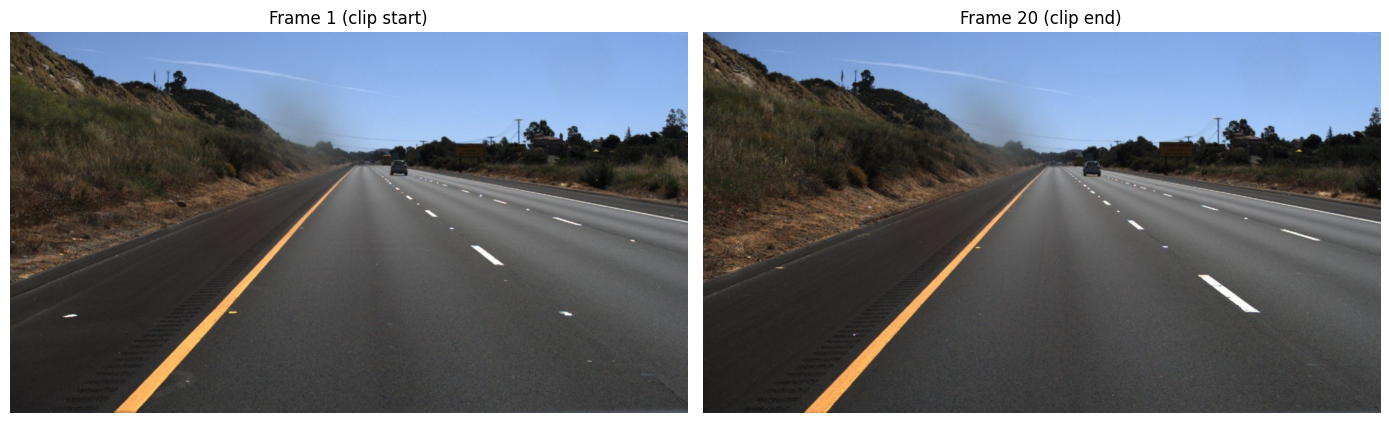

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

import cv2
import numpy as np
import matplotlib.pyplot as plt

from pipeline import ClassicalPipeline
from temporal import EMASmoother

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["figure.dpi"] = 100

CLIP_ID = "1492626760788443246_0"
clip_dir = project_root / "data/tusimple/test_subset/clips/0530" / CLIP_ID

# Load all 20 frames in order
frame_paths = sorted(clip_dir.glob("*.jpg"), key=lambda p: int(p.stem))
print(f"Clip: {CLIP_ID}")
print(f"Frame count: {len(frame_paths)}")
print(f"First frame: {frame_paths[0].name}")
print(f"Last frame:  {frame_paths[-1].name}")

# Load all 20 frames into memory (each is ~200KB, so 4MB total — fine)
frames_rgb = []
for p in frame_paths:
    img = cv2.imread(str(p))
    frames_rgb.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

print(f"Loaded {len(frames_rgb)} frames, each shape {frames_rgb[0].shape}")

# Show first and last frame side by side to confirm they're a real sequence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(frames_rgb[0]); axes[0].set_title("Frame 1 (clip start)"); axes[0].axis("off")
axes[1].imshow(frames_rgb[-1]); axes[1].set_title("Frame 20 (clip end)"); axes[1].axis("off")
plt.tight_layout()
plt.show()

## 2. Run both pipelines

We process each frame with:
- The raw `ClassicalPipeline` (no memory between frames)
- The `EMASmoother` (alpha=0.25, max_consecutive_misses=5)

For each frame, we record both the raw detection and the smoothed result.

In [2]:
# Build pipelines
raw_pipeline = ClassicalPipeline()
smoother = EMASmoother(alpha=0.25, max_consecutive_misses=5)

# Process all frames
raw_results = []
smoothed_results = []

for i, frame in enumerate(frames_rgb):
    # Raw detection — independent per frame
    raw = raw_pipeline.detect(frame)
    raw_results.append(raw)
    
    # Smoothed detection — stateful across frames
    smoothed = smoother.process(frame)
    smoothed_results.append(smoothed)

# Quick summary
n_raw_left = sum(1 for r in raw_results if r.left_detected)
n_raw_right = sum(1 for r in raw_results if r.right_detected)
n_sm_left = sum(1 for s in smoothed_results if s.smoothed_left is not None)
n_sm_right = sum(1 for s in smoothed_results if s.smoothed_right is not None)

print(f"=== Detection counts (out of {len(frames_rgb)} frames) ===")
print(f"  Raw left detected:      {n_raw_left}")
print(f"  Raw right detected:     {n_raw_right}")
print(f"  Smoothed left output:   {n_sm_left}")
print(f"  Smoothed right output:  {n_sm_right}")
print()

# Count fallback usage
n_fb_left = sum(1 for s in smoothed_results if s.used_fallback_left)
n_fb_right = sum(1 for s in smoothed_results if s.used_fallback_right)
print(f"=== Smoother fallback usage ===")
print(f"  Left lane carried forward:  {n_fb_left} frames")
print(f"  Right lane carried forward: {n_fb_right} frames")

=== Detection counts (out of 20 frames) ===
  Raw left detected:      20
  Raw right detected:     20
  Smoothed left output:   20
  Smoothed right output:  20

=== Smoother fallback usage ===
  Left lane carried forward:  0 frames
  Right lane carried forward: 0 frames


## 3. Coefficient evolution: raw vs. smoothed

Plot the polynomial `c` coefficient (constant term ≈ lane x-position at top)
for both raw and smoothed across the 20 frames. The expected pattern:
- Raw line: jagged, with spikes or dropouts at failure frames
- Smoothed line: continuous and smooth, possibly with flat segments
  where it carried forward through detection failures

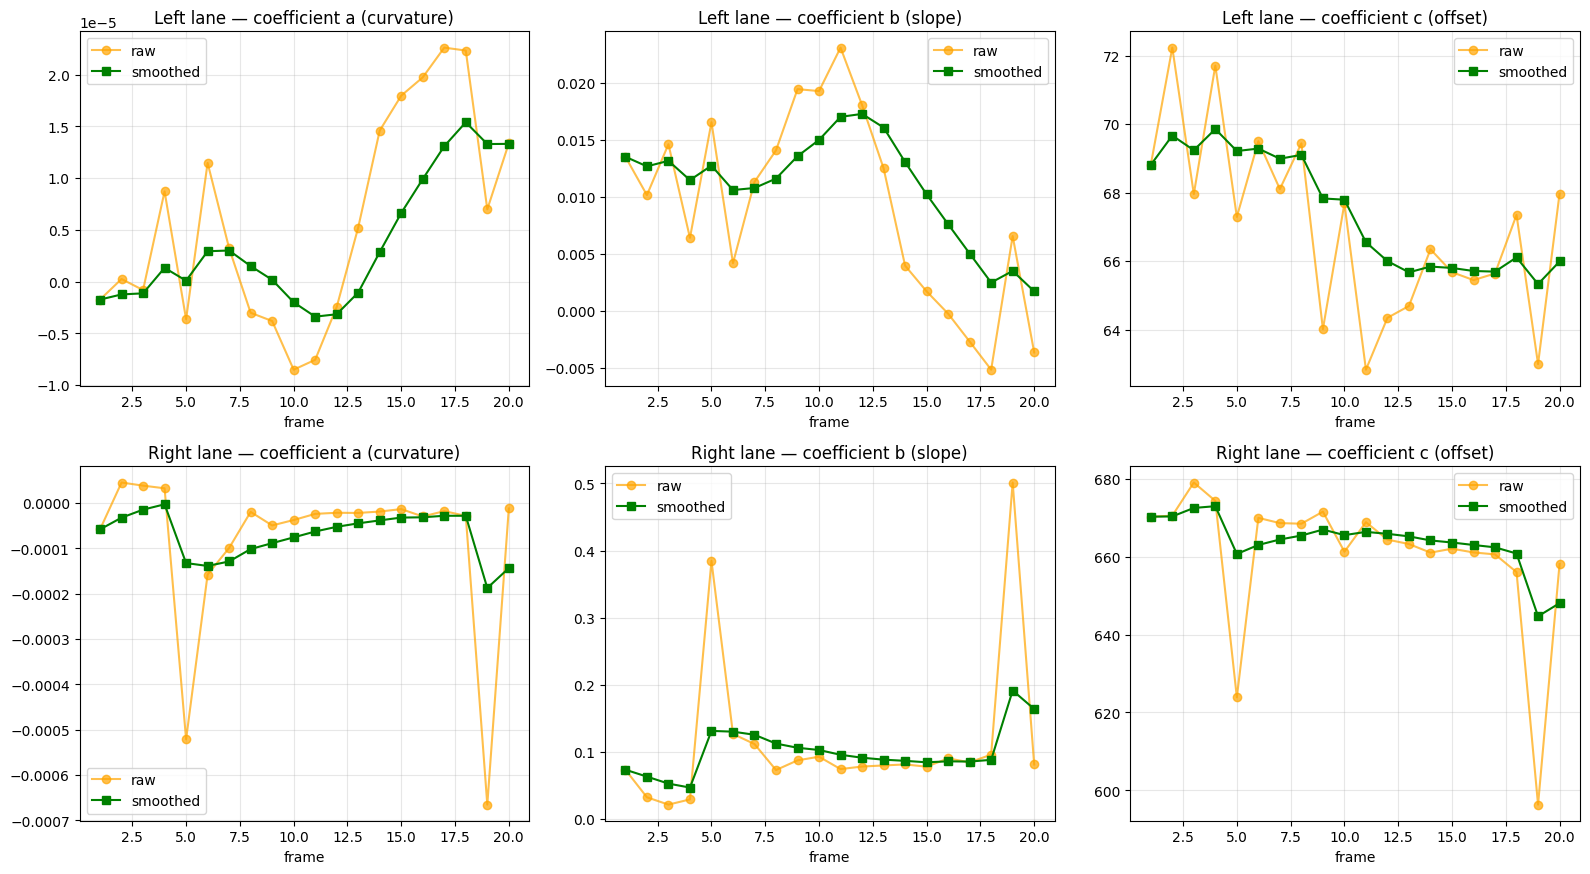


=== Frame-to-frame jitter (std of consecutive differences) ===
                            a           b           c
  left  raw:      0.000008      0.0066        3.17
  left  smooth:   0.000002      0.0017        0.57
  right raw:      0.000261      0.1683       25.49
  right smooth:   0.000049      0.0314        4.69


In [3]:
def get_coeffs_history(results, kind: str, side: str):
    """Extract per-frame polynomial coefficients [a, b, c] for plotting.
    Returns (frame_indices, a_values, b_values, c_values) for plotting.
    Missing frames produce NaN entries."""
    a_arr, b_arr, c_arr = [], [], []
    for r in results:
        if kind == "raw":
            coeffs = r.left_coeffs if side == "left" else r.right_coeffs
        else:  # "smoothed"
            coeffs = r.smoothed_left if side == "left" else r.smoothed_right
        if coeffs is None:
            a_arr.append(np.nan); b_arr.append(np.nan); c_arr.append(np.nan)
        else:
            a_arr.append(coeffs[0])
            b_arr.append(coeffs[1])
            c_arr.append(coeffs[2])
    return np.array(a_arr), np.array(b_arr), np.array(c_arr)


frames_idx = np.arange(1, len(frames_rgb) + 1)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, side in enumerate(["left", "right"]):
    raw_a, raw_b, raw_c = get_coeffs_history(raw_results, "raw", side)
    sm_a, sm_b, sm_c = get_coeffs_history(smoothed_results, "smoothed", side)
    
    axes[col, 0].plot(frames_idx, raw_a, "o-", color="orange", label="raw", alpha=0.7)
    axes[col, 0].plot(frames_idx, sm_a, "s-", color="green", label="smoothed")
    axes[col, 0].set_title(f"{side.capitalize()} lane — coefficient a (curvature)")
    axes[col, 0].set_xlabel("frame"); axes[col, 0].legend(); axes[col, 0].grid(alpha=0.3)
    
    axes[col, 1].plot(frames_idx, raw_b, "o-", color="orange", label="raw", alpha=0.7)
    axes[col, 1].plot(frames_idx, sm_b, "s-", color="green", label="smoothed")
    axes[col, 1].set_title(f"{side.capitalize()} lane — coefficient b (slope)")
    axes[col, 1].set_xlabel("frame"); axes[col, 1].legend(); axes[col, 1].grid(alpha=0.3)
    
    axes[col, 2].plot(frames_idx, raw_c, "o-", color="orange", label="raw", alpha=0.7)
    axes[col, 2].plot(frames_idx, sm_c, "s-", color="green", label="smoothed")
    axes[col, 2].set_title(f"{side.capitalize()} lane — coefficient c (offset)")
    axes[col, 2].set_xlabel("frame"); axes[col, 2].legend(); axes[col, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / "results" / "temporal_coefficients_comparison.png",
            dpi=120, bbox_inches="tight")
plt.show()

# Compute jitter — standard deviation of frame-to-frame differences
def compute_jitter(coeffs):
    """How much does the coefficient bounce around frame-to-frame?
    Smaller = smoother. NaN values are dropped first."""
    valid = coeffs[~np.isnan(coeffs)]
    if len(valid) < 2:
        return float("nan")
    diffs = np.diff(valid)
    return float(np.std(diffs))

print(f"\n=== Frame-to-frame jitter (std of consecutive differences) ===")
print(f"                   {'a':>10}  {'b':>10}  {'c':>10}")
for side in ["left", "right"]:
    raw_a, raw_b, raw_c = get_coeffs_history(raw_results, "raw", side)
    sm_a, sm_b, sm_c = get_coeffs_history(smoothed_results, "smoothed", side)
    print(f"  {side:5} raw:    {compute_jitter(raw_a):>10.6f}  {compute_jitter(raw_b):>10.4f}  {compute_jitter(raw_c):>10.2f}")
    print(f"  {side:5} smooth: {compute_jitter(sm_a):>10.6f}  {compute_jitter(sm_b):>10.4f}  {compute_jitter(sm_c):>10.2f}")

## 4. Per-frame visual comparison (image grid)

Render every frame's overlay side-by-side: raw on the left, smoothed on the right.
This is the static version of the side-by-side video.

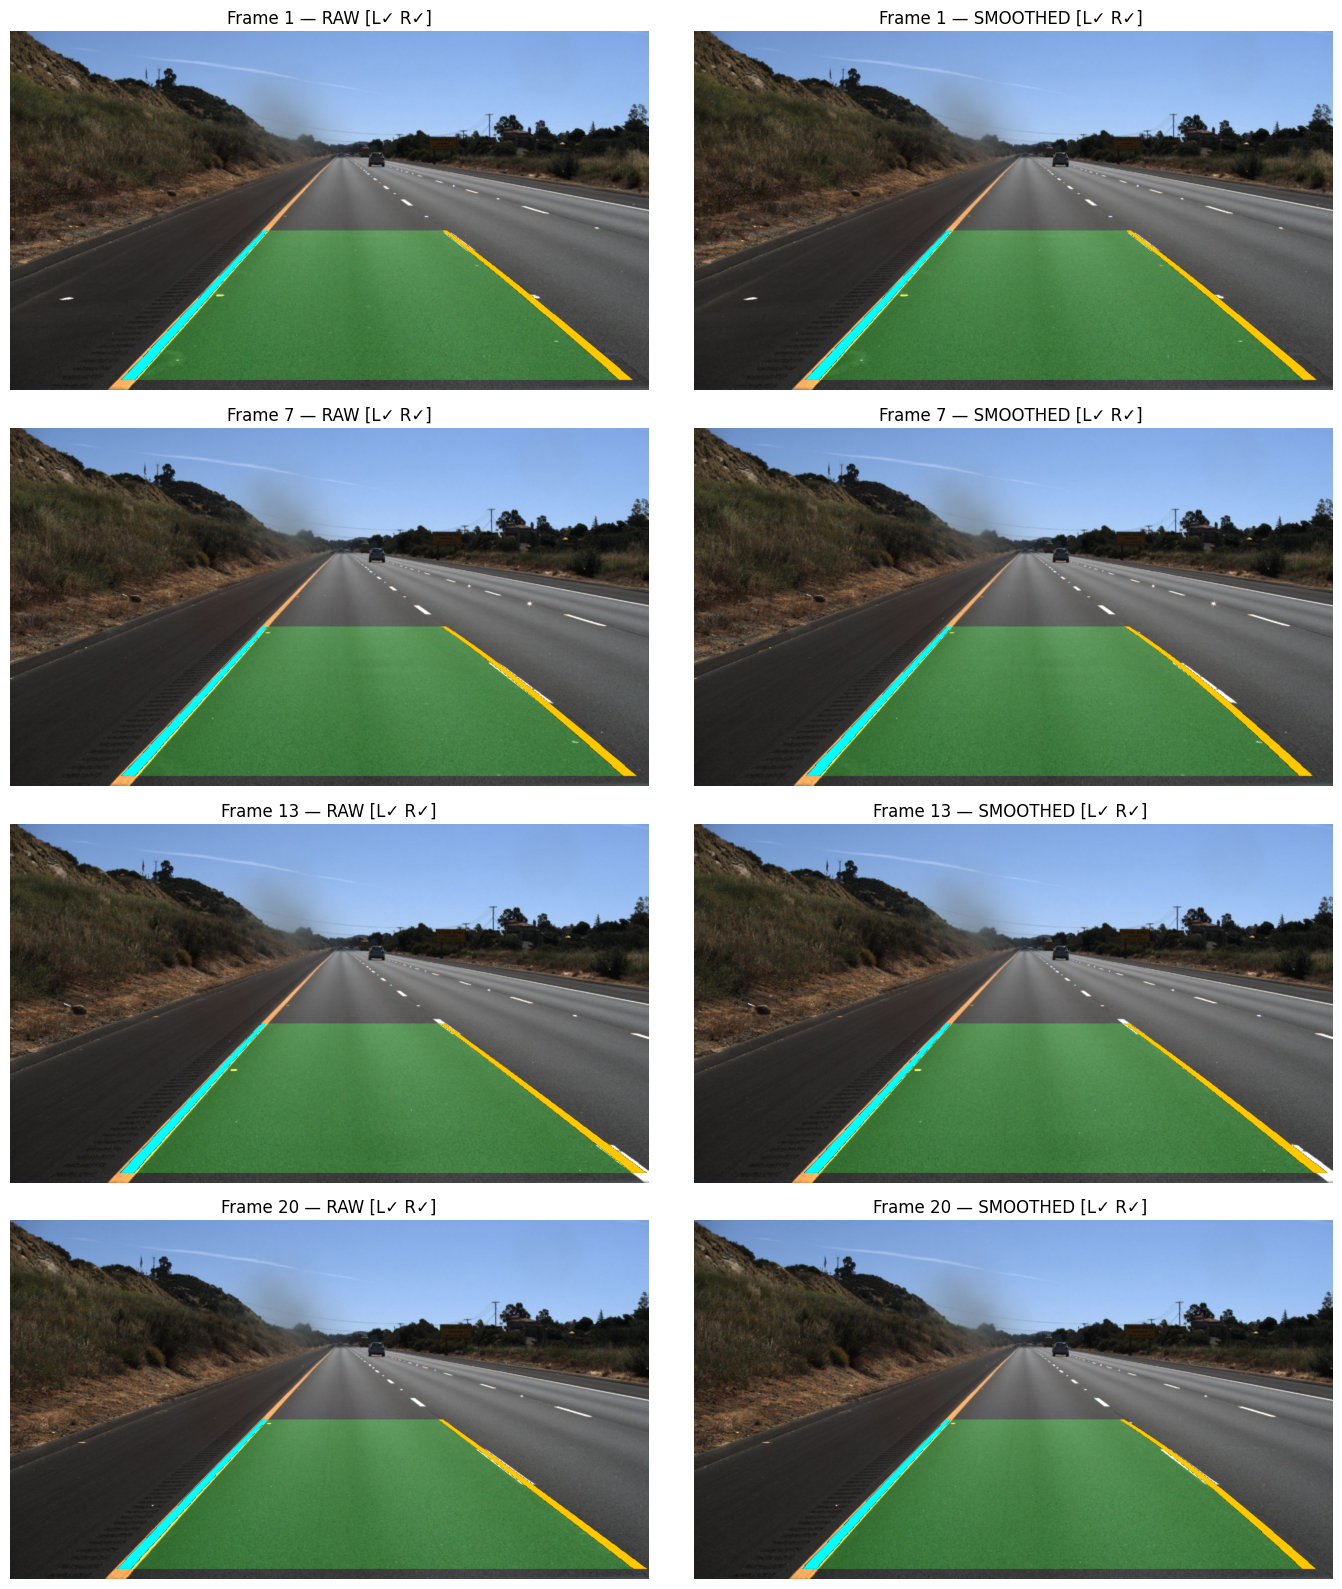

In [4]:
def render_smoothed_overlay(image_rgb, smoothed_result, pipeline, raw_result):
    """Build a smoothed-result LaneDetectionResult so we can reuse pipeline.draw_overlay."""
    from pipeline import LaneDetectionResult
    fake = LaneDetectionResult(
        left_coeffs=smoothed_result.smoothed_left,
        right_coeffs=smoothed_result.smoothed_right,
        left_detected=smoothed_result.smoothed_left is not None,
        right_detected=smoothed_result.smoothed_right is not None,
        bev=raw_result.bev,
        mask=raw_result.mask,
        sliding_window_diagnostics=raw_result.sliding_window_diagnostics,
    )
    return pipeline.draw_overlay(image_rgb, fake)


# Show 4 sample frames as a grid (frames 1, 7, 13, 20 — beginning, middle, end)
sample_frame_indices = [0, 6, 12, 19]
fig, axes = plt.subplots(len(sample_frame_indices), 2, figsize=(14, 4 * len(sample_frame_indices)))

for row, frame_i in enumerate(sample_frame_indices):
    frame = frames_rgb[frame_i]
    raw_overlay = raw_pipeline.draw_overlay(frame, raw_results[frame_i])
    smooth_overlay = render_smoothed_overlay(frame, smoothed_results[frame_i],
                                              raw_pipeline, raw_results[frame_i])
    
    raw = raw_results[frame_i]
    sm = smoothed_results[frame_i]
    
    raw_status = (("L✓" if raw.left_detected else "L✗")
                  + " " + ("R✓" if raw.right_detected else "R✗"))
    sm_status = (("L✓" if sm.smoothed_left is not None else "L✗")
                 + " " + ("R✓" if sm.smoothed_right is not None else "R✗"))
    sm_fb = ("(carry-fwd L)" if sm.used_fallback_left else "") + \
            ("(carry-fwd R)" if sm.used_fallback_right else "")
    
    axes[row, 0].imshow(raw_overlay)
    axes[row, 0].set_title(f"Frame {frame_i + 1} — RAW [{raw_status}]")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(smooth_overlay)
    axes[row, 1].set_title(f"Frame {frame_i + 1} — SMOOTHED [{sm_status}] {sm_fb}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.savefig(project_root / "results" / "temporal_grid_comparison.png",
            dpi=120, bbox_inches="tight")
plt.show()

## 5. Render side-by-side comparison video

A video is far more compelling than static images for this contribution.
We write an MP4 file that shows raw on the left and smoothed on the right,
with a labeled separator. Open it from the file explorer or run it in any
video player to see the temporal smoothing effect.

Note: TuSimple clips are 20 frames at 20 fps = ~1 second of real-time. We slow
to 5 fps so the viewer can see each frame's behavior clearly.

In [5]:
def write_side_by_side_video(
    frames_rgb,
    raw_results,
    smoothed_results,
    pipeline,
    output_path: Path,
    fps: int = 5,
):
    """Write a side-by-side comparison MP4 video file."""
    H, W = frames_rgb[0].shape[:2]
    
    # Output frame: two side-by-side images + a separator strip
    SEP = 8  # pixels of separator strip
    out_W = W * 2 + SEP
    out_H = H + 60  # extra room for header text
    
    # MP4 writer — H.264 codec for compatibility
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (out_W, out_H))
    
    if not writer.isOpened():
        raise RuntimeError(f"Failed to open VideoWriter for {output_path}")
    
    for i, frame in enumerate(frames_rgb):
        raw_overlay = pipeline.draw_overlay(frame, raw_results[i])
        smooth_overlay = render_smoothed_overlay(frame, smoothed_results[i],
                                                  pipeline, raw_results[i])
        
        # Compose
        canvas = np.zeros((out_H, out_W, 3), dtype=np.uint8)
        canvas[60:, :W] = raw_overlay
        canvas[60:, W:W+SEP] = (255, 255, 255)  # white separator
        canvas[60:, W+SEP:] = smooth_overlay
        
        # Headers
        cv2.putText(canvas, f"RAW (single-frame)  -  frame {i+1}/20",
                    (20, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        cv2.putText(canvas, f"SMOOTHED (EMA, alpha=0.25)  -  frame {i+1}/20",
                    (W + SEP + 20, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        
        # Write (cv2 expects BGR)
        writer.write(cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR))
    
    writer.release()
    print(f"Wrote video: {output_path}")


output_video = project_root / "results" / "temporal_comparison.mp4"
output_video.parent.mkdir(parents=True, exist_ok=True)
write_side_by_side_video(frames_rgb, raw_results, smoothed_results,
                          raw_pipeline, output_video, fps=5)
print(f"Open the file from the explorer to view: {output_video}")

Wrote video: c:\dev\lane-detection-cv\results\temporal_comparison.mp4
Open the file from the explorer to view: c:\dev\lane-detection-cv\results\temporal_comparison.mp4


## 6. Aggregate evaluation across all 5 video clips

A single 20-frame clip is a small sample. To make the jitter-reduction
claim more credible, we run the same comparison on **all 5 clips** that
have full 20-frame downloads. We aggregate the jitter statistics into
a summary table.

This still isn't a long video, but 100 frames is 5x our previous evidence
and includes scenes the smoother might struggle with (curves, faded lanes).

In [7]:
# Process every full clip in the test_subset
clip_root = project_root / "data/tusimple/test_subset/clips/0530"
all_clip_dirs = sorted([d for d in clip_root.iterdir()
                         if d.is_dir() and len(list(d.glob("*.jpg"))) == 20])
print(f"Found {len(all_clip_dirs)} full 20-frame clips for evaluation")
print()

# Per-clip jitter results
all_jitters = []  # list of dicts

for clip_dir in all_clip_dirs:
    clip_id = clip_dir.name
    
    # Load all frames
    paths = sorted(clip_dir.glob("*.jpg"), key=lambda p: int(p.stem))
    frames = []
    for p in paths:
        img = cv2.imread(str(p))
        frames.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    
    # Reset smoother for this independent clip
    pipe = ClassicalPipeline()
    sm = EMASmoother(alpha=0.25, max_consecutive_misses=5)
    
    raws = []
    smooths = []
    for f in frames:
        raws.append(pipe.detect(f))
        smooths.append(sm.process(f))
    
    # Compute jitter for each side and coefficient
    for side in ["left", "right"]:
        raw_a, raw_b, raw_c = get_coeffs_history(raws, "raw", side)
        sm_a, sm_b, sm_c = get_coeffs_history(smooths, "smoothed", side)
        
        all_jitters.append({
            "clip": clip_id[:18] + "...",
            "side": side,
            "raw_a_jitter": compute_jitter(raw_a),
            "sm_a_jitter": compute_jitter(sm_a),
            "raw_b_jitter": compute_jitter(raw_b),
            "sm_b_jitter": compute_jitter(sm_b),
            "raw_c_jitter": compute_jitter(raw_c),
            "sm_c_jitter": compute_jitter(sm_c),
            "n_raw_detected": sum(1 for r in raws
                                   if (r.left_detected if side == "left" else r.right_detected)),
            "n_sm_output":    sum(1 for s in smooths
                                   if (s.smoothed_left if side == "left" else s.smoothed_right) is not None),
            "n_fallback":     sum(1 for s in smooths
                                   if (s.used_fallback_left if side == "left" else s.used_fallback_right)),
        })
    
    print(f"  Done: {clip_id}")

# Print a summary table
print()
print("=" * 100)
print(f"{'Clip':<22} {'Side':<6} {'raw_c':>8} {'sm_c':>8} {'reduction':>10} "
      f"{'n_raw':>6} {'n_sm':>6} {'n_fb':>6}")
print("=" * 100)

for row in all_jitters:
    reduction = row["raw_c_jitter"] / max(row["sm_c_jitter"], 1e-10)
    print(f"{row['clip']:<22} {row['side']:<6} "
          f"{row['raw_c_jitter']:>8.2f} {row['sm_c_jitter']:>8.2f} "
          f"{reduction:>9.1f}× "
          f"{row['n_raw_detected']:>6} {row['n_sm_output']:>6} {row['n_fallback']:>6}")

# Aggregate averages
print("=" * 100)
avg_raw_c = np.mean([r["raw_c_jitter"] for r in all_jitters])
avg_sm_c = np.mean([r["sm_c_jitter"] for r in all_jitters])
avg_reduction = avg_raw_c / max(avg_sm_c, 1e-10)

total_fallback = sum(r["n_fallback"] for r in all_jitters)
total_frames = len(all_jitters) * 20

print(f"AVERAGE c-coefficient jitter:  raw={avg_raw_c:.2f}, smoothed={avg_sm_c:.2f}, "
      f"reduction={avg_reduction:.1f}×")
print(f"Carry-forward usage: {total_fallback} / {total_frames} frame-lanes "
      f"({100 * total_fallback / total_frames:.1f}%)")


# Save the table as a CSV for the report
import csv
csv_path = project_root / "results" / "temporal_jitter_per_clip.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(all_jitters[0].keys()))
    writer.writeheader()
    writer.writerows(all_jitters)
print(f"\nSaved table: {csv_path}")

Found 5 full 20-frame clips for evaluation

  Done: 1492626397007603377_0
  Done: 1492626617873533069_0
  Done: 1492626760788443246_0
  Done: 1492627171538356342_0
  Done: 1492627288467128445_0

Clip                   Side      raw_c     sm_c  reduction  n_raw   n_sm   n_fb
149262639700760337...  left       2.80     0.72       3.9×     20     20      0
149262639700760337...  right      5.46     1.33       4.1×     20     20      0
149262661787353306...  left       4.07     0.80       5.1×     20     20      0
149262661787353306...  right      3.05     0.62       4.9×     20     20      0
149262676078844324...  left       3.17     0.57       5.5×     20     20      0
149262676078844324...  right     25.49     4.69       5.4×     20     20      0
149262717153835634...  left       4.81     1.45       3.3×     20     20      0
149262717153835634...  right      6.81     1.91       3.6×     20     20      0
149262728846712844...  left       7.54     2.46       3.1×     20     20      0
14926